# Entrega 2 · Cómo se le gana a quién: estilos de juego ATP

**Grupo 5K10-05 · Ciencia de Datos · UTN FRM · 23 de septiembre de 2026**

Este notebook está ejecutado y conserva sus resultados. Analiza el Silver real,
define la unidad jugador–superficie para el futuro clustering y deja cerrada la
tabla de columnas que se llevará a la Entrega 3.

## 0. Pregunta de investigación y operacionalización

> **¿Existen estilos de juego diferenciables entre los tenistas del circuito ATP
> según sus patrones de saque y golpeo? ¿Hay estilos globalmente superiores, y
> el emparejamiento de estilos predice el ganador de un partido por encima del ranking?**

La pregunta se divide en tres decisiones medibles:

1. **Estilos por superficie.** Un mismo jugador puede recibir un estilo diferente
   en cemento, clay y grass. La unidad del clustering será una fila
   jugador–superficie, con tasas de saque y devolución. H2 decide una redundancia y deja siete rasgos finales.
2. **Superioridad.** Las tasas de victoria no forman los clusters: se reservan
   para evaluar después si algún estilo gana más globalmente y por superficie.
3. **Predicción.** En una tabla auxiliar por partido, el modelo base usa ranking
   y contexto; el ampliado agregará estilo de A, estilo de B y su interacción.

La fuente no ofrece velocidad de derecha, revés o spin. Por eso “golpeo” se
operacionaliza con los patrones disponibles de saque, segundo saque, break
points y devolución; `tipo-reves` queda como contexto biográfico, no como
medición completa del golpe.

In [1]:
from pathlib import Path
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

actual = Path.cwd().resolve()
opciones = [actual, *actual.parents, actual / 'Proyecto']
ROOT = next(p for p in opciones if (p / 'airflow-atp/include/output/silver/atp_jugadores.csv').exists())
BASE = ROOT / 'entrega2'
OUT = BASE / 'resultados'
FIG = OUT / 'graficos'
FIG.mkdir(parents=True, exist_ok=True)
SILVER = ROOT / 'airflow-atp/include/output/silver'
RUTAS = {'jugadores': SILVER / 'atp_jugadores.csv', 'partidos': SILVER / 'partidos_consolidado.csv'}
HUELLAS = {k: hashlib.sha256(p.read_bytes()).hexdigest() for k, p in RUTAS.items()}
SEMILLA, CORTE = 42, 2023
MIN_PARTIDOS, MIN_PUNTOS, MIN_COBERTURA = 20, 500, .80
pd.set_option('display.max_columns', 12)
pd.set_option('display.max_rows', 18)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams.update({'figure.figsize': (9, 4.2), 'figure.dpi': 110,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titleweight': 'bold', 'axes.grid': True, 'grid.alpha': .16,
    'font.size': 10, 'savefig.facecolor': 'white'})
AZUL, VERDE, ROJO = '#2563eb', '#0f766e', '#b91c1c'

# Muestra una conclusión en formato Markdown.
def texto(s): display(Markdown(s))
# Guarda una tabla y, si corresponde, la muestra.
def exportar(tabla, nombre, mostrar=True):
    tabla.to_csv(OUT / f'{nombre}.csv', index=False, encoding='utf-8-sig')
    if mostrar: display(tabla)
# Guarda y muestra el gráfico activo.
def grafico(nombre):
    plt.tight_layout()
    plt.savefig(FIG / f'{nombre}.png', dpi=160, bbox_inches='tight')
    plt.show()
# Divide solamente cuando el denominador es positivo.
def division(n, d): return n / d.where(d > 0)

df_csv = pd.read_csv(RUTAS['jugadores'], dtype={'id-jugador': 'string'}, low_memory=False)
df = df_csv.copy()
df['fecha-nacimiento'] = pd.to_datetime(df['fecha-nacimiento'], errors='coerce')
for c in ['mano-dominante', 'tipo-reves', 'pais']:
    df[c] = df[c].astype('category')
partidos = pd.read_csv(RUTAS['partidos'], dtype={'winner_id':'string', 'loser_id':'string'}, low_memory=False)
partidos['fecha'] = pd.to_datetime(partidos['fecha'], errors='coerce')
partidos['anio'] = partidos['fecha'].dt.year
assert df['id-jugador'].notna().all() and df['id-jugador'].is_unique
assert partidos['id_partido'].is_unique
n_challenger = int(partidos.tourney_level.astype(str).eq('C').sum())
n_qualy = int(partidos['round'].astype(str).str.fullmatch(r'Q[1-4]').sum())
texto(f'**Datos locales:** {len(df):,} jugadores × {df.shape[1]} columnas; '
      f'{len(partidos):,} partidos × {partidos.shape[1]} columnas. '
      f'Fechas: {partidos.fecha.min():%Y-%m-%d} a {partidos.fecha.max():%Y-%m-%d}.  '
      f'Filas Challenger detectadas: {n_challenger:,}; rondas Qualifying detectadas: {n_qualy:,}.')


**Datos locales:** 1,450 jugadores × 157 columnas; 77,474 partidos × 55 columnas. Fechas: 2000-01-03 a 2025-12-22.  Filas Challenger detectadas: 0; rondas Qualifying detectadas: 0.

## 1. Perfil completo: tamaño, tipos, nulos, constantes y duplicados

`id-jugador` es un identificador, aunque algunos IDs parezcan números. Los conteos
pueden leerse como `float` porque provienen de sumas con faltantes; eso no los
convierte en variables continuas del dominio. `fecha-nacimiento` se convierte
explícitamente en fecha; un CSV no conserva tipos de pandas.

,tipo,columnas
0,float64,134
1,int64,17
2,category,3
3,string,1
4,str,1
5,datetime64[us],1


,columna,nulos,pct_nulos,datos_disponibles,detalle
0,nombre-jugador,0,0.0000,1450,Variable personal
1,fecha-nacimiento,2,0.1400,1448,Variable personal
2,altura-cm,161,11.1000,1289,Variable personal
3,peso-kg,149,10.2800,1301,Variable personal
4,mano-dominante,71,4.9000,1379,Variable personal
5,tipo-reves,452,31.1700,998,Variable personal
6,año-profesional,444,30.6200,1006,Variable personal
7,pais,1,0.0700,1449,Variable personal
8,grass (38 columnas agrupadas),609,42.0000,841,24 columnas con nulos; rango 586-622


**Duplicados de clave: 0. Duplicados de fila completa: 0. Columnas 100% nulas: 0. Constantes: ['titulos-1000-grass'].**

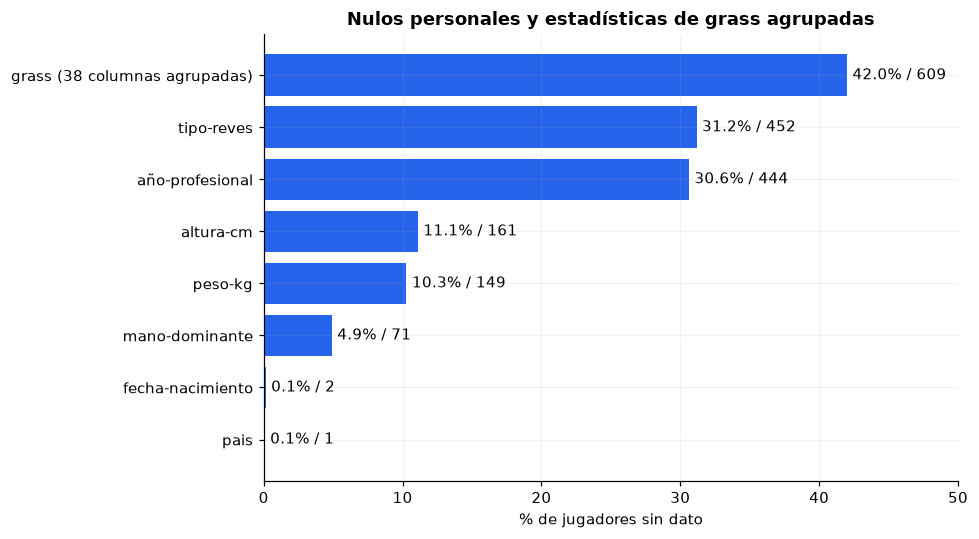

In [2]:
perfil = pd.DataFrame({'columna': df.columns, 'tipo_csv': df_csv.dtypes.astype(str).values,
    'tipo_analitico': df.dtypes.astype(str).values, 'nulos': df.isna().sum().values,
    'pct_nulos': 100 * df.isna().mean().values,
    'valores_distintos': df.nunique(dropna=True).values})
perfil['constante_o_vacia'] = perfil['valores_distintos'] <= 1
perfil['asimetria'] = perfil['columna'].map(df.select_dtypes('number').skew())
exportar(perfil, 'perfil_columnas_silver', False)
display(pd.DataFrame({'tipo': df.dtypes.astype(str).value_counts().index,
                     'columnas': df.dtypes.astype(str).value_counts().values}))

columnas_personales = ['nombre-jugador', 'fecha-nacimiento', 'altura-cm', 'peso-kg',
                       'mano-dominante', 'tipo-reves', 'año-profesional', 'pais']
nulos_personales = perfil.set_index('columna').loc[columnas_personales, ['nulos', 'pct_nulos']].reset_index()
nulos_personales['datos_disponibles'] = len(df) - nulos_personales['nulos']
nulos_personales['detalle'] = 'Variable personal'

perfil_grass = perfil.loc[perfil.columna.str.endswith('-grass')].copy()
grass_con_nulos = perfil_grass.loc[perfil_grass.nulos.gt(0)]
nulos_grass_tipicos = int(grass_con_nulos.nulos.mode().iloc[0])
resumen_grass = pd.DataFrame([{
    'columna': f'grass ({len(perfil_grass)} columnas agrupadas)',
    'nulos': nulos_grass_tipicos,
    'pct_nulos': 100 * nulos_grass_tipicos / len(df),
    'datos_disponibles': len(df) - nulos_grass_tipicos,
    'detalle': (f'{len(grass_con_nulos)} columnas con nulos; rango '
                f'{int(grass_con_nulos.nulos.min())}-{int(grass_con_nulos.nulos.max())}')
}])
resumen_nulos_eda = pd.concat([nulos_personales, resumen_grass], ignore_index=True)
resumen_nulos_eda['pct_nulos'] = resumen_nulos_eda['pct_nulos'].round(2)
display(resumen_nulos_eda)
exportar(resumen_nulos_eda, 'resumen_nulos_eda', False)

constantes = perfil.loc[perfil.constante_o_vacia, 'columna'].tolist()
texto(f'**Duplicados de clave: {df["id-jugador"].duplicated().sum()}. '
      f'Duplicados de fila completa: {df.duplicated().sum()}. '
      f'Columnas 100% nulas: {df.isna().all().sum()}. Constantes: {constantes}.**')
assert (df['partidos-totales'] == df['victorias-totales'] + df['derrotas-totales']).all()
for m in ['partidos', 'victorias', 'derrotas', 'partidos-validos', 'partidos-validos-resto']:
    assert np.allclose(df[f'{m}-totales'], df[[f'{m}-{s}' for s in ['cemento','clay','grass']]].sum(axis=1))

fig, ax = plt.subplots(figsize=(9,5))
nulos_grafico = resumen_nulos_eda.loc[resumen_nulos_eda.nulos.gt(0)].sort_values('pct_nulos')
ax.barh(nulos_grafico.columna, nulos_grafico.pct_nulos, color=AZUL)
for i,v in enumerate(nulos_grafico.pct_nulos):
    ax.text(v+.4, i, f'{v:.1f}% / {int(nulos_grafico.iloc[i].nulos)}', va='center')
ax.set(xlabel='% de jugadores sin dato',
       title='Nulos personales y estadísticas de grass agrupadas', xlim=(0,50))
grafico('01_nulos')

**Decisiones sobre faltantes y cobertura:**
- Las variables personales se muestran individualmente porque tienen causas y coberturas diferentes.
- Las 38 columnas de grass se presentan en una única fila para evitar repetir el mismo patrón. El valor mostrado es el más frecuente: 609 nulos (42%); entre las 24 columnas afectadas el rango real es 586-622.
- `tipo-reves`, `año-profesional`, `altura-cm` y `peso-kg` dependen de la biografía; un nulo significa desconocido.
- Las estadísticas de saque no se rellenan con cero cuando el bloque del partido está incompleto.
- `partidos-validos-*` cuenta participaciones con estadísticas utilizables.
- `cobertura-saque-*` y `cobertura-resto-*` dividen esos partidos válidos por los partidos registrados.

Un cero en títulos o conteos puede significar que el jugador no acumuló ese evento. En cambio,
una tasa sin denominador u oportunidades queda como `NaN`. Las tasas del Silver
se encuentran entre 0 y 1 y se calculan de la misma forma para totales, cemento,
clay y grass.

## 2. Tasas, devolución y cobertura ya calculadas en Silver

El EDA no reconstruye las tasas generales desde los partidos. Lee directamente
las columnas creadas por `build_player_dataset`: totales auditables, tasas de
saque, métricas de devolución y cobertura.

La devolución se deriva de las estadísticas del rival:

- puntos ganados al resto = puntos de saque del rival - primeros y segundos ganados por el rival;
- break points convertidos = oportunidades enfrentadas por el rival - break points salvados por el rival.

Estas aproximaciones no miden desplazamiento, winners ni errores no forzados.
Por eso ayudan a formar perfiles de devolución, pero no bastan por sí solas para
llamar “defensivo” a un jugador.


In [3]:
RATIOS = {
    'tasa_aces': 'tasa-aces-totales',
    'tasa_dobles_faltas': 'tasa-dobles-faltas-totales',
    'primer_saque_dentro': 'tasa-primer-saque-dentro-totales',
    'efectividad_primero': 'efectividad-primer-saque-totales',
    'efectividad_segundo': 'efectividad-segundo-saque-totales',
    'bp_salvados': 'tasa-break-points-salvados-totales',
    'puntos_ganados_resto': 'tasa-puntos-ganados-resto-totales',
    'bp_convertidos': 'tasa-break-points-convertidos-totales',
}
SIGNIFICADOS = {
    'tasa_aces':'Aces / puntos de saque: frecuencia de puntos ganados directamente con el servicio.',
    'tasa_dobles_faltas':'Dobles faltas / puntos de saque: frecuencia de errores de ambos servicios.',
    'primer_saque_dentro':'Primeros saques dentro / puntos de saque: regularidad del primer servicio.',
    'efectividad_primero':'Puntos ganados con primer saque / primeros saques dentro: éxito cuando entra.',
    'efectividad_segundo':'Puntos ganados con segundo saque / intentos de segundo saque.',
    'bp_salvados':'Break points salvados / enfrentados: quiebres evitados al sacar.',
    'puntos_ganados_resto':'Puntos que el rival no ganó al sacar / puntos de saque del rival.',
    'bp_convertidos':'Break points no salvados por el rival / oportunidades del jugador.',
}
columnas_perfil = ['id-jugador','nombre-jugador','altura-cm','mano-dominante',
    'partidos-totales','victorias-totales','aces-totales','puntos-saque-totales',
    'partidos-validos-totales','partidos-validos-resto-totales',
    'cobertura-saque-totales','cobertura-resto-totales',
    'partidos-cemento','partidos-clay','partidos-grass',
    'tasa-victorias-cemento','tasa-victorias-clay','tasa-victorias-grass',
    *RATIOS.values()]
perfil_jugadores = df[columnas_perfil].rename(columns={
    'altura-cm':'altura', 'mano-dominante':'mano',
    'partidos-totales':'partidos', 'victorias-totales':'victorias',
    'aces-totales':'aces_total', 'puntos-saque-totales':'puntos_saque',
    'cobertura-saque-totales':'cobertura_saque',
    'cobertura-resto-totales':'cobertura_resto',
    'partidos-cemento':'partidos_cemento','partidos-clay':'partidos_clay',
    'partidos-grass':'partidos_grass','tasa-victorias-cemento':'winrate_cemento',
    'tasa-victorias-clay':'winrate_clay','tasa-victorias-grass':'winrate_grass',
    **{v:k for k,v in RATIOS.items()},
}).set_index('id-jugador')
perfil_jugadores['winrate'] = division(perfil_jugadores.victorias, perfil_jugadores.partidos)

exportar(pd.DataFrame([{'variable':c,'columna_silver':RATIOS[c],
    'que_mide_y_formula':SIGNIFICADOS[c]} for c in RATIOS]), 'diccionario_tasas')
auditoria = perfil_jugadores[['nombre-jugador','partidos','aces_total','puntos_saque',
    'cobertura_saque','cobertura_resto','tasa_aces']].reset_index()
exportar(auditoria, 'auditoria_ceros_y_cobertura', False)
ceros_medidos = auditoria.aces_total.eq(0) & auditoria.cobertura_saque.gt(0)
sin_cobertura = auditoria.cobertura_saque.fillna(0).eq(0)
texto(f'**Ceros de aces con medición disponible: {int(ceros_medidos.sum())}. '
      f'Jugadores sin cobertura de saque: {int(sin_cobertura.sum())}.** '
      'El Silver preserva NaN cuando no hay una tasa definida; no reconstruimos el dato en el EDA.')
display(auditoria.sort_values('cobertura_saque').head(8))

elegibles = (perfil_jugadores.partidos >= MIN_PARTIDOS) & (perfil_jugadores.puntos_saque >= MIN_PUNTOS) & (perfil_jugadores.cobertura_saque >= MIN_COBERTURA)
dominio = perfil_jugadores.loc[elegibles].copy()
exportar(pd.DataFrame([
    {'poblacion':'Silver completo', 'jugadores':len(df)},
    {'poblacion':'Silver con >=20 partidos', 'jugadores':int(perfil_jugadores.partidos.ge(20).sum())},
    {'poblacion':'>=20 + 500 puntos de saque + 80% cobertura', 'jugadores':len(dominio)},
    {'poblacion':'Anterior con cobertura de resto >=80%', 'jugadores':int(dominio.cobertura_resto.ge(.8).sum())},
]), 'poblaciones_analiticas')


# Convierte el Silver ancho en la unidad que usará el clustering: jugador-superficie.
SUPERFICIES = ['cemento', 'clay', 'grass']
partes_superficie = []
for superficie_nombre in SUPERFICIES:
    bloque = pd.DataFrame({
        'id-jugador': df['id-jugador'],
        'nombre-jugador': df['nombre-jugador'],
        'superficie': superficie_nombre,
        'altura': df['altura-cm'],
        'partidos': df[f'partidos-{superficie_nombre}'],
        'winrate': df[f'tasa-victorias-{superficie_nombre}'],
        'cobertura_saque': df[f'cobertura-saque-{superficie_nombre}'],
        'cobertura_resto': df[f'cobertura-resto-{superficie_nombre}'],
    })
    for nombre_interno, columna_total in RATIOS.items():
        bloque[nombre_interno] = df[columna_total.replace('-totales', f'-{superficie_nombre}')]
    partes_superficie.append(bloque)

perfiles_superficie = pd.concat(partes_superficie, ignore_index=True)
perfiles_superficie['informacion_suficiente'] = (
    perfiles_superficie.partidos.ge(20)
    & perfiles_superficie.cobertura_saque.ge(MIN_COBERTURA)
    & perfiles_superficie.cobertura_resto.ge(MIN_COBERTURA)
    & perfiles_superficie[list(RATIOS)].notna().all(axis=1)
)
resumen_perfiles_superficie = perfiles_superficie.groupby('superficie').agg(
    perfiles=('id-jugador','size'),
    con_partidos=('partidos',lambda x:int(x.gt(0).sum())),
    utilizables=('informacion_suficiente','sum')
).reset_index()
display(resumen_perfiles_superficie)
exportar(resumen_perfiles_superficie, 'perfiles_utilizables_por_superficie', False)
texto(f'**Unidad para clustering:** {int(perfiles_superficie.informacion_suficiente.sum()):,} perfiles confiables '
      'jugador–superficie. La superficie identifica la fila, pero no entra como variable numérica del clustering.')

,variable,columna_silver,que_mide_y_formula
0,tasa_aces,tasa-aces-totales,Aces / puntos de saque: frecuencia de puntos g...
1,tasa_dobles_faltas,tasa-dobles-faltas-totales,Dobles faltas / puntos de saque: frecuencia de...
2,primer_saque_dentro,tasa-primer-saque-dentro-totales,Primeros saques dentro / puntos de saque: regu...
3,efectividad_primero,efectividad-primer-saque-totales,Puntos ganados con primer saque / primeros saq...
4,efectividad_segundo,efectividad-segundo-saque-totales,Puntos ganados con segundo saque / intentos de...
5,bp_salvados,tasa-break-points-salvados-totales,Break points salvados / enfrentados: quiebres ...
6,puntos_ganados_resto,tasa-puntos-ganados-resto-totales,Puntos que el rival no ganó al sacar / puntos ...
7,bp_convertidos,tasa-break-points-convertidos-totales,Break points no salvados por el rival / oportu...


**Ceros de aces con medición disponible: 29. Jugadores sin cobertura de saque: 0.** El Silver preserva NaN cuando no hay una tasa definida; no reconstruimos el dato en el EDA.

,id-jugador,nombre-jugador,partidos,aces_total,puntos_saque,cobertura_saque,cobertura_resto,tasa_aces
579,I236,Uladzimir Ignatik,28,4.0000,60.0000,0.0357,0.0357,0.0667
1283,T264,Marko Tkalec,27,7.0000,94.0000,0.0370,0.0370,0.0745
439,G478,Pablo Gonzalez,18,3.0000,87.0000,0.0556,0.0556,0.0345
1158,S585,Jimy Szymanski,18,0.0000,54.0000,0.0556,0.0556,0.0000
824,M744,Karim Maamoun,18,0.0000,43.0000,0.0556,0.0556,0.0000
150,BG25,Duilio Beretta,17,2.0000,42.0000,0.0588,0.0588,0.0476
1294,T879,Patrick Tierro,17,1.0000,56.0000,0.0588,0.0588,0.0179
1231,SK06,David Souto,16,3.0000,99.0000,0.0625,0.0625,0.0303


,poblacion,jugadores
0,Silver completo,1450
1,Silver con >=20 partidos,730
2,>=20 + 500 puntos de saque + 80% cobertura,639
3,Anterior con cobertura de resto >=80%,639


,superficie,perfiles,con_partidos,utilizables
0,cemento,1450,1357,514
1,clay,1450,1249,451
2,grass,1450,864,259


**Unidad para clustering:** 1,224 perfiles confiables jugador–superficie. La superficie identifica la fila, pero no entra como variable numérica del clustering.

**Alcance del Silver y unidad analítica:** las estadísticas ya vienen separadas
en totales, cemento, clay y grass. Para construir estilos no se entregan todas
las columnas de superficie juntas en una fila: se pasa a formato largo, con una
fila por jugador y superficie.

Se parte de ocho tasas técnicas. H2 demuestra que `tasa_aces` y
`efectividad_primero` son casi redundantes; se conserva `tasa_aces`, por su
interpretación directa, y el conjunto final queda en siete rasgos.

Se exigen >=20 partidos y >=80% de cobertura de saque y resto en esa superficie.
Esto deja 514 perfiles de cemento, 451 de clay y 259 de grass. Quien no cumple
queda como **información insuficiente**. Los perfiles se estandarizarán dentro
de cada superficie y luego se ajustará un clustering común, sin usar victorias,
ranking, títulos ni el nombre de la superficie.

Las tasas de victoria por superficie se reservan para responder si un estilo es
superior. Para predecir partidos históricos, los estilos deberán calcularse sólo
con información anterior al encuentro.

## 3. Asimetría, extremos y decisiones de transformación

La asimetría se calcula para **todas** las columnas numéricas. Se considera cola
larga cuando su valor absoluto es mayor o igual que 1. El signo indica la dirección:
positivo, cola hacia valores altos; negativo, cola hacia valores bajos.

La decisión no depende sólo del número. Los conteos acumulados se comparan con
`log1p`; las tasas se conservan por su interpretación como estilo y se escalarán
antes del clustering; los resultados y títulos no se usan para formar los grupos.
La tabla completa queda exportada y aquí se muestran las variables relevantes.

,columna,asimetria,asimetria_absoluta,cola_larga,asimetria_log1p,decision
0,partidos-totales,2.9741,2.9741,Sí,0.4725,log1p sólo si entra como control; no define el...
1,victorias-totales,4.3092,4.3092,Sí,0.4968,excluir del clustering; resultado acumulado
2,aces-totales,4.5969,4.5969,Sí,0.0974,preferir tasa-aces; log1p sólo si se usa el co...
3,puntos-saque-totales,2.9120,2.9120,Sí,0.2068,usar para cobertura; log1p sólo como control
4,break-points-oportunidades-totales,3.5237,3.5237,Sí,0.1243,preferir la tasa; log1p sólo como control
5,altura-cm,0.1483,0.1483,No,NaN,mantener sin transformación y escalar
6,peso-kg,1.0440,1.0440,Sí,NaN,revisar el extremo de 151 kg; no transformar a...
7,tasa-aces-totales,1.0729,1.0729,Sí,NaN,mantener; filtrar cobertura y escalar antes de...
8,tasa-dobles-faltas-totales,1.8188,1.8188,Sí,NaN,mantener; filtrar cobertura y escalar antes de...
9,tasa-primer-saque-dentro-totales,-0.1204,0.1204,No,NaN,mantener; filtrar cobertura y escalar antes de...


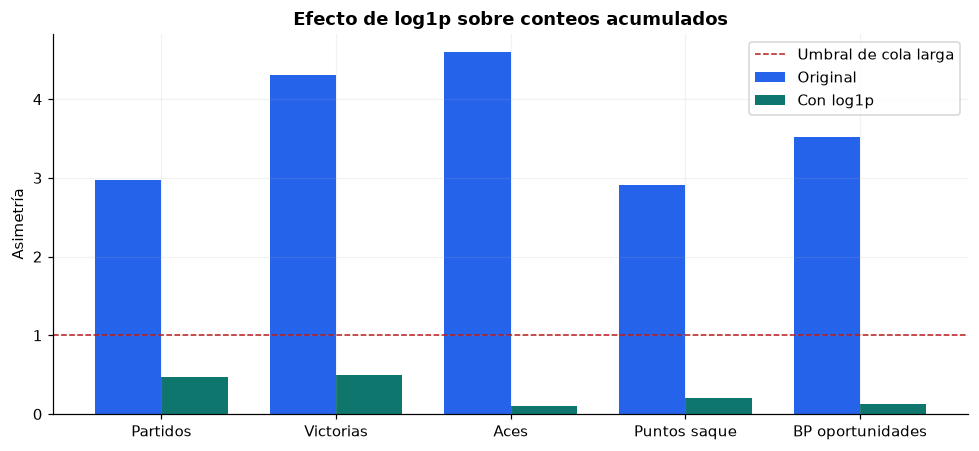

**Decisión:** los conteos reducen su asimetría con `log1p`, pero no se usarán para definir estilos. En la tabla auxiliar ya se usan `dif_partidos_log` y `dif_log_ranking`. Altura se conserva; peso requiere revisar el valor extremo de 151 kg. Las tasas se mantienen y se escalarán después del filtro de cobertura.

### Dimensión temporal y cobertura de la fuente

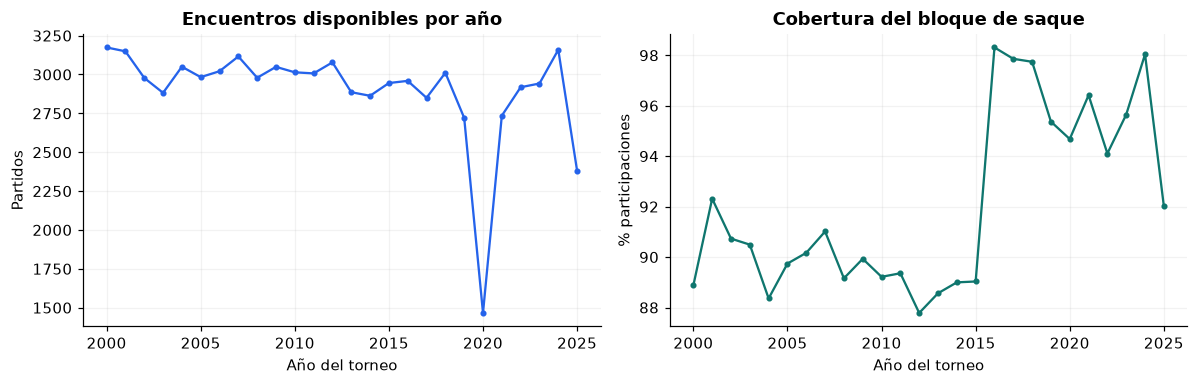

In [4]:
asim_series = df.select_dtypes('number').skew()
asim = asim_series.rename('asimetria').to_frame()
asim['asimetria_absoluta'] = asim.asimetria.abs()
asim['cola_larga'] = np.where(asim.asimetria_absoluta.ge(1), 'Sí', 'No')
asim = asim.sort_values('asimetria_absoluta', ascending=False).reset_index(names='columna')

conteos_revision = ['partidos-totales', 'victorias-totales', 'aces-totales',
                     'puntos-saque-totales', 'break-points-oportunidades-totales']
tasas_revision = ['tasa-aces-totales', 'tasa-dobles-faltas-totales',
                   'tasa-primer-saque-dentro-totales', 'efectividad-primer-saque-totales',
                   'efectividad-segundo-saque-totales', 'tasa-break-points-salvados-totales',
                   'tasa-puntos-ganados-resto-totales',
                   'tasa-break-points-convertidos-totales']
fisicas_revision = ['altura-cm', 'peso-kg']

decision_asimetria = asim.set_index('columna').loc[
    conteos_revision + fisicas_revision + tasas_revision,
    ['asimetria', 'asimetria_absoluta', 'cola_larga']
].reset_index()
decision_asimetria['asimetria_log1p'] = np.nan
for c in conteos_revision:
    decision_asimetria.loc[decision_asimetria.columna.eq(c), 'asimetria_log1p'] = np.log1p(df[c]).skew()

decisiones = {
    'partidos-totales': 'log1p sólo si entra como control; no define el estilo',
    'victorias-totales': 'excluir del clustering; resultado acumulado',
    'aces-totales': 'preferir tasa-aces; log1p sólo si se usa el conteo',
    'puntos-saque-totales': 'usar para cobertura; log1p sólo como control',
    'break-points-oportunidades-totales': 'preferir la tasa; log1p sólo como control',
    'altura-cm': 'mantener sin transformación y escalar',
    'peso-kg': 'revisar el extremo de 151 kg; no transformar automáticamente',
}
for c in tasas_revision:
    decisiones[c] = 'mantener; filtrar cobertura y escalar antes del clustering'
decision_asimetria['decision'] = decision_asimetria.columna.map(decisiones)

cols_titulos = [c for c in asim_series.index if c.startswith('titulos-')]
titulo_extremo = asim_series.loc[cols_titulos].abs().idxmax()
fila_titulos = pd.DataFrame([{
    'columna': f'titulos-* ({len(cols_titulos)} columnas agrupadas)',
    'asimetria': asim_series[titulo_extremo],
    'asimetria_absoluta': abs(asim_series[titulo_extremo]),
    'cola_larga': 'Sí',
    'asimetria_log1p': np.nan,
    'decision': f'excluir del clustering; máximo en {titulo_extremo}'
}])
decision_asimetria = pd.concat([decision_asimetria, fila_titulos], ignore_index=True)
for c in ['asimetria', 'asimetria_absoluta', 'asimetria_log1p']:
    decision_asimetria[c] = decision_asimetria[c].round(4)

display(decision_asimetria)
exportar(asim, 'asimetria_columnas', False)
exportar(decision_asimetria, 'decisiones_asimetria', False)

comparacion = decision_asimetria.loc[
    decision_asimetria.columna.isin(conteos_revision),
    ['columna', 'asimetria', 'asimetria_log1p']
].copy()
etiquetas = ['Partidos', 'Victorias', 'Aces', 'Puntos saque', 'BP oportunidades']
x = np.arange(len(comparacion))
fig, ax = plt.subplots(figsize=(9,4.2))
ax.bar(x-.19, comparacion.asimetria, width=.38, label='Original', color=AZUL)
ax.bar(x+.19, comparacion.asimetria_log1p, width=.38, label='Con log1p', color=VERDE)
ax.axhline(1, color=ROJO, linestyle='--', linewidth=1, label='Umbral de cola larga')
ax.set(xticks=x, xticklabels=etiquetas, ylabel='Asimetría',
       title='Efecto de log1p sobre conteos acumulados')
ax.legend()
grafico('02_asimetria_transformaciones')

texto(f'**Decisión:** los conteos reducen su asimetría con `log1p`, pero no se usarán para definir estilos. '
      f'En la tabla auxiliar ya se usan `dif_partidos_log` y `dif_log_ranking`. '
      f'Altura se conserva; peso requiere revisar el valor extremo de {df["peso-kg"].max():.0f} kg. '
      'Las tasas se mantienen y se escalarán después del filtro de cobertura.')

texto('### Dimensión temporal y cobertura de la fuente')
superficie_valida = partidos.surface.isin(['Hard', 'Clay', 'Grass'])
p = partidos.loc[superficie_valida].copy()
stats_w = [f'w_{c}' for c in ['ace','df','svpt','1stIn','1stWon','2ndWon','SvGms','bpSaved','bpFaced']]
stats_l = [f'l_{c}' for c in ['ace','df','svpt','1stIn','1stWon','2ndWon','SvGms','bpSaved','bpFaced']]
valid_w = p[stats_w].apply(pd.to_numeric, errors='coerce').notna().all(axis=1)
valid_l = p[stats_l].apply(pd.to_numeric, errors='coerce').notna().all(axis=1)
temporal = p.groupby('anio').size().rename('partidos').reset_index()
cob = pd.concat([pd.DataFrame({'anio':p.anio,'valido':valid_w}),
                 pd.DataFrame({'anio':p.anio,'valido':valid_l})]).groupby('anio').valido.mean()
temporal['cobertura_saque'] = temporal.anio.map(cob)
exportar(temporal, 'cobertura_por_anio', False)
fig, axes = plt.subplots(1,2,figsize=(11,3.6))
axes[0].plot(temporal.anio, temporal.partidos, marker='.', color=AZUL)
axes[0].set(title='Encuentros disponibles por año', xlabel='Año del torneo', ylabel='Partidos')
axes[1].plot(temporal.anio, temporal.cobertura_saque*100, marker='.', color=VERDE)
axes[1].set(title='Cobertura del bloque de saque', xlabel='Año del torneo', ylabel='% participaciones')
grafico('03_tiempo_y_cobertura')

## 4. Objetivo supervisado real: `gana_a`

El clustering de estilos no tiene objetivo. Para la pregunta supervisada se
construye una tabla auxiliar de modelado con una fila por partido. La asignación A/B se
decide con semilla 42, independiente de quién ganó; `gana_a` vale 1 si ganó A y
0 si ganó B.

Las tasas del Silver completo sirven para describir jugadores, pero no pueden
usarse para predecir partidos históricos porque incluyen información posterior.
Por eso esta sección vuelve al consolidado únicamente para construir historiales
anteriores a cada año. Esa reconstrucción pertenece a la tabla auxiliar, no reemplaza las
tasas generales del Silver.


,periodo,gana_a,partidos,proporcion
0,desarrollo,0,21257,0.5039
1,desarrollo,1,20930,0.4961
2,reserva_2023_2025,0,2756,0.5076
3,reserva_2023_2025,1,2673,0.4924


,etapa,partidos
0,Partidos en superficies admitidas,75316
1,Resultado completo,72628
2,Ambos con >=20 partidos históricos,47710
3,Además ambos rankings conocidos,47616
4,Desarrollo (<2023),42187
5,Reserva 2023-2025,5429


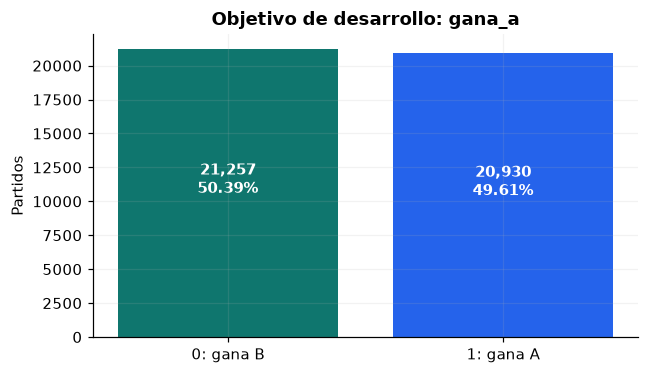

**Clase mayoritaria de desarrollo: 50.39%.** El orden A/B es independiente del resultado. La tabla A/B es auxiliar; el Silver continúa con una fila por jugador.

In [5]:
# Construye participaciones únicamente para el historial temporal de la tabla auxiliar.
def lado_historico(prefijo, rival, persona, gano):
    z = p[['id_partido','fecha','anio','surface','tourney_level','score']].copy()
    z['id-jugador'] = p[f'{persona}_id']
    z['altura'] = pd.to_numeric(p[f'{persona}_ht'], errors='coerce')
    z['victoria'] = gano
    z['partidos'] = 1
    for c in ['ace','df','svpt','1stIn','1stWon','2ndWon','bpSaved','bpFaced']:
        z[c] = pd.to_numeric(p[f'{prefijo}_{c}'], errors='coerce')
    for c in ['svpt','1stWon','2ndWon','bpSaved','bpFaced']:
        z[f'rival_{c}'] = pd.to_numeric(p[f'{rival}_{c}'], errors='coerce')
    return z

largo = pd.concat([lado_historico('w','l','winner',1), lado_historico('l','w','loser',0)], ignore_index=True)
largo['segundos_intentos'] = largo.svpt - largo['1stIn']
largo['resto_ganados'] = largo.rival_svpt - largo.rival_1stWon - largo.rival_2ndWon
largo['quiebres'] = largo.rival_bpFaced - largo.rival_bpSaved
RATIOS_HIST = {
    'tasa_aces': ('ace','svpt'), 'tasa_dobles_faltas': ('df','svpt'),
    'primer_saque_dentro': ('1stIn','svpt'), 'efectividad_primero': ('1stWon','1stIn'),
    'efectividad_segundo': ('2ndWon','segundos_intentos'), 'bp_salvados': ('bpSaved','bpFaced'),
    'puntos_ganados_resto': ('resto_ganados','rival_svpt'), 'bp_convertidos': ('quiebres','rival_bpFaced'),
}
sumables = ['partidos','victoria']
for nombre,(num,den) in RATIOS_HIST.items():
    validos = largo[num].notna() & largo[den].notna() & largo[num].ge(0) & largo[den].gt(0) & largo[num].le(largo[den])
    largo[nombre+'_num'] = largo[num].where(validos)
    largo[nombre+'_den'] = largo[den].where(validos)
    sumables += [nombre+'_num',nombre+'_den']

def con_tasas_historicas(t):
    t = t.copy()
    for nombre in RATIOS_HIST:
        t[nombre] = division(t[nombre+'_num'],t[nombre+'_den'])
    t['winrate'] = division(t.victoria,t.partidos)
    return t

anual = largo.groupby(['id-jugador','anio'])[sumables].sum(min_count=1).reset_index().sort_values(['id-jugador','anio'])
cant = anual[sumables].fillna(0)
previos = cant.groupby(anual['id-jugador']).cumsum() - cant
hist = pd.concat([anual[['id-jugador','anio']].reset_index(drop=True),previos.reset_index(drop=True)],axis=1)
hist = con_tasas_historicas(hist)
hist['max_anio_historial'] = anual.groupby('id-jugador')['anio'].shift(1).to_numpy()
HIST_FEATURES = list(RATIOS_HIST) + ['winrate','partidos','max_anio_historial']

sin_juego = p.score.fillna('').str.contains(r'W/O|\bWO\b|RET|DEF|ABN', case=False, regex=True)
base_ab = p.loc[~sin_juego & p.score.notna()].sort_values(['fecha','id_partido']).copy()
rng = np.random.default_rng(SEMILLA)
a_ganador = rng.random(len(base_ab)) < .5
ab = base_ab[['id_partido','fecha','anio','surface','tourney_level','best_of']].reset_index(drop=True)
ab['gana_a'] = a_ganador.astype(int)
for suf,cond in [('a',a_ganador),('b',~a_ganador)]:
    for origen,destino in [('id','id'),('rank','ranking'),('ht','altura'),('age','edad')]:
        ab[f'{destino}_{suf}'] = np.where(cond,base_ab[f'winner_{origen}'],base_ab[f'loser_{origen}'])
    ab[f'id_{suf}'] = ab[f'id_{suf}'].astype('string')
    for c in ['ranking','altura','edad']:
        ab[f'{c}_{suf}'] = pd.to_numeric(ab[f'{c}_{suf}'],errors='coerce')
    h = hist[['id-jugador','anio']+HIST_FEATURES].rename(columns={
        'id-jugador':f'id_{suf}', **{c:f'{c}_{suf}' for c in HIST_FEATURES}})
    ab = ab.merge(h,on=[f'id_{suf}','anio'],how='left',validate='many_to_one')
    assert (ab[f'max_anio_historial_{suf}'].dropna() < ab.loc[ab[f'max_anio_historial_{suf}'].notna(),'anio']).all()

for c in list(RATIOS_HIST)+['winrate','altura','edad']:
    ab['dif_'+c] = ab[f'{c}_a'] - ab[f'{c}_b']
ab['dif_partidos_log'] = np.log1p(ab.partidos_a) - np.log1p(ab.partidos_b)
rank_ok = ab.ranking_a.gt(0) & ab.ranking_b.gt(0)
ab['dif_ranking'] = (ab.ranking_a-ab.ranking_b).where(rank_ok)
ab['dif_log_ranking'] = np.log(ab.ranking_a.where(rank_ok))-np.log(ab.ranking_b.where(rank_ok))
ab['historial_suficiente'] = ab.partidos_a.ge(MIN_PARTIDOS) & ab.partidos_b.ge(MIN_PARTIDOS)
ab['periodo'] = np.where(ab.anio < CORTE,'desarrollo','reserva_2023_2025')
modelo = ab.loc[ab.historial_suficiente & rank_ok].copy()
dev = modelo.loc[modelo.anio < CORTE].copy()
assert modelo.id_partido.is_unique and set(modelo.gana_a.unique()) == {0,1}
balance = modelo.groupby(['periodo','gana_a']).size().rename('partidos').reset_index()
balance['proporcion'] = balance.partidos / balance.groupby('periodo').partidos.transform('sum')
exportar(balance,'distribucion_objetivo')
exportar(pd.DataFrame([
    {'etapa':'Partidos en superficies admitidas','partidos':len(p)},
    {'etapa':'Resultado completo','partidos':len(ab)},
    {'etapa':'Ambos con >=20 partidos históricos','partidos':int(ab.historial_suficiente.sum())},
    {'etapa':'Además ambos rankings conocidos','partidos':len(modelo)},
    {'etapa':'Desarrollo (<2023)','partidos':len(dev)},
    {'etapa':'Reserva 2023-2025','partidos':int(modelo.anio.ge(CORTE).sum())},
]),'trazabilidad_tabla_ab')
fig,ax=plt.subplots(figsize=(6,3.5))
b=dev.gana_a.value_counts().sort_index()
ax.bar(['0: gana B','1: gana A'],b.values,color=[VERDE,AZUL])
for i,v in enumerate(b): ax.text(i,v*.5,f'{v:,}\n{v/len(dev):.2%}',ha='center',color='white',fontweight='bold')
ax.set(title='Objetivo de desarrollo: gana_a',ylabel='Partidos')
grafico('04_objetivo')
texto(f'**Clase mayoritaria de desarrollo: {b.max()/b.sum():.2%}.** '
      'El orden A/B es independiente del resultado. La tabla A/B es auxiliar; el Silver continúa con una fila por jugador.')
exportar(modelo,'partidos_ab_historial_anual',False)


## 5. Cinco fichas de hipótesis

Las hipótesis responden partes no triviales de la pregunta: confiabilidad de los
perfiles jugador-superficie, redundancia entre variables de saque, adaptación
entre superficies, aporte predictivo más allá del ranking y compromiso entre
aces y dobles faltas. H1-H3 y H5 utilizan el Silver; H4 utiliza la tabla auxiliar
histórica para respetar el tiempo.

| Medida | Rojo | Amarillo | Verde |
|---|---|---|---|
| Correlación (valor absoluto) | <0,2 | 0,2-0,6 | >0,6 |
| Separación estandarizada | <0,2 | 0,2-0,8 | >0,8 |
| eta cuadrado | <0,05 | 0,05-0,25 | >0,25 |

Verde y rojo terminan la prueba. Sólo amarillo habilita un movimiento elegido
por el gráfico. Si después del segundo movimiento sigue amarillo, la hipótesis
queda inconclusa.

In [6]:
CORTES = {'correlacion':(.2,.6),'separacion':(.2,.8),'eta2':(.05,.25),'brecha':(.05,.15)}
# Asigna la zona del semáforo según los cortes fijados.
def zona(v, m):
    if pd.isna(v): return 'no estimable'
    a,b = CORTES[m]
    return 'rojo' if abs(v)<a else 'verde' if abs(v)>b else 'amarillo'
# Calcula Pearson, Spearman y su brecha.
def asociacion(x,y):
    v=pd.concat([x,y],axis=1).dropna()
    pear=v.iloc[:,0].corr(v.iloc[:,1])
    spe=v.iloc[:,0].rank().corr(v.iloc[:,1].rank())
    return {'n':len(v),'pearson':pear,'spearman':spe,'brecha':spe-pear}
# Compara dos grupos en desviaciones estándar.
def separacion(x,y):
    x,y=x.dropna(),y.dropna()
    den=np.sqrt((x.std()**2+y.std()**2)/2)
    return abs(x.mean()-y.mean())/den if den>0 else np.nan
# Calcula la proporción de varianza explicada por los grupos.
def eta2(x,c):
    v=pd.DataFrame({'x':x,'c':c}).dropna()
    g=v.groupby('c').x
    total=((v.x-v.x.mean())**2).sum()
    return (g.count()*(g.mean()-v.x.mean())**2).sum()/total if total>0 else np.nan
fichas=[]
# Registra y presenta los seis campos de una hipótesis.
def ficha(id, tipo, afirmacion, expectativa, medida, resultado, movimiento, decision, valor, metrica, estado, n):
    row=dict(id=id,tipo=tipo,afirmacion=afirmacion,expectativa=expectativa,medida=medida,
             resultado=resultado,movimiento=movimiento,decision=decision,valor=float(valor),
             zona=zona(valor,metrica),estado=estado,n=int(n))
    fichas.append(row)
    texto('\n\n'.join([f'### {id} · {tipo}',f'**1. Afirmación.** {afirmacion}',
        f'**2. Qué espero ver.** {expectativa}',f'**3. Medida y gráfico.** {medida}',
        f'**4. Resultado y zona.** {resultado}',f'**5. Movimiento.** {movimiento}',
        f'**6. Qué hago con eso.** {decision}']))

### H1 · Pocos partidos y valores extremos
**Antes de calcular:** espero que los perfiles jugador–superficie con menos de
20 partidos presenten valores mucho más extremos en la efectividad del segundo
saque que los perfiles confiables: separación estandarizada >0,8.

“Extremo” significa distancia absoluta a la mediana de la misma superficie,
dividida por su rango intercuartílico. Así no se confunde que grass, clay y
cemento tengan niveles normales diferentes. No se eliminan jugadores.

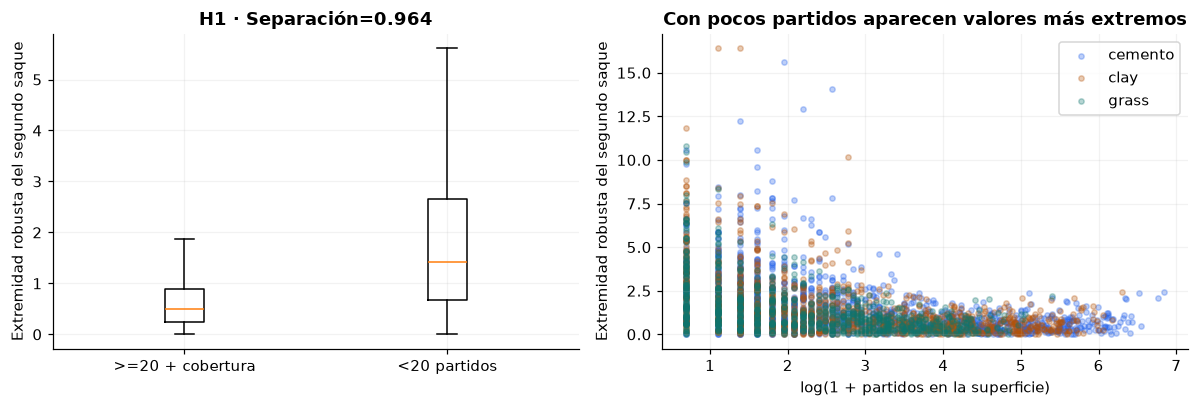

### H1 · Pocos partidos y valores extremos

**1. Afirmación.** Los perfiles con pocos partidos presentan valores más extremos de efectividad del segundo saque.

**2. Qué espero ver.** Separación >0,8 y sobrerrepresentación de perfiles con <20 partidos entre el 5% más extremo.

**3. Medida y gráfico.** Separación de la distancia robusta a la mediana por superficie; H1_pocos_partidos_valores_extremos.png.

**4. Resultado y zona.** n=3252 perfiles; separación=0.9644 (verde); perfiles <20 global=59.9%; entre el 5% más extremo=100.0% (n=165). CONFIRMADA.

**5. Movimiento.** 0 movimientos: la medida inicial llega a verde y la regla exige detenerse.

**6. Qué hago con eso.** No interpretar un valor extremo con pocos partidos como habilidad estable. El mínimo de 20 partidos se conserva como filtro de confiabilidad.

In [7]:
h1m = perfiles_superficie.dropna(subset=['efectividad_segundo']).copy()
h1m['confiable'] = (
    h1m.partidos.ge(20)
    & h1m.cobertura_saque.ge(MIN_COBERTURA)
    & h1m.cobertura_resto.ge(MIN_COBERTURA)
)
h1m['extremo_segundo_saque'] = np.nan
for nombre_superficie, indices in h1m.groupby('superficie').groups.items():
    grupo = h1m.loc[indices]
    referencia = grupo.loc[grupo.confiable, 'efectividad_segundo']
    mediana = referencia.median()
    iqr = referencia.quantile(.75) - referencia.quantile(.25)
    h1m.loc[indices, 'extremo_segundo_saque'] = (
        (grupo.efectividad_segundo - mediana).abs() / iqr
    )

ext_pocos = h1m.loc[h1m.partidos.lt(20), 'extremo_segundo_saque']
ext_confiables = h1m.loc[h1m.confiable, 'extremo_segundo_saque']
h1_sep = separacion(ext_pocos, ext_confiables)
h1m['outlier'] = h1m.groupby('superficie').extremo_segundo_saque.transform(
    lambda x: x.ge(x.quantile(.95)))
prop_pocos_global = h1m.partidos.lt(20).mean()
prop_pocos_outlier = h1m.loc[h1m.outlier, 'partidos'].lt(20).mean()

fig, axes = plt.subplots(1,2,figsize=(11,3.8))
axes[0].boxplot([ext_confiables, ext_pocos],
                tick_labels=['>=20 + cobertura','<20 partidos'],showfliers=False)
axes[0].set(ylabel='Extremidad robusta del segundo saque',title=f'H1 · Separación={h1_sep:.3f}')
colores_superficie={'cemento':AZUL,'clay':'#b45309','grass':VERDE}
for nombre_superficie, grupo in h1m.groupby('superficie'):
    axes[1].scatter(np.log1p(grupo.partidos),grupo.extremo_segundo_saque,s=12,alpha=.3,
                    color=colores_superficie[nombre_superficie],label=nombre_superficie)
axes[1].set(xlabel='log(1 + partidos en la superficie)',
            ylabel='Extremidad robusta del segundo saque',
            title='Con pocos partidos aparecen valores más extremos')
axes[1].legend()
grafico('H1_pocos_partidos_valores_extremos')

z1 = zona(h1_sep,'separacion')
estado1 = 'confirmada' if z1=='verde' else 'refutada' if z1=='rojo' else 'inconclusa'
ficha('H1','Pocos partidos y valores extremos',
    'Los perfiles con pocos partidos presentan valores más extremos de efectividad del segundo saque.',
    'Separación >0,8 y sobrerrepresentación de perfiles con <20 partidos entre el 5% más extremo.',
    'Separación de la distancia robusta a la mediana por superficie; H1_pocos_partidos_valores_extremos.png.',
    f'n={len(h1m)} perfiles; separación={h1_sep:.4f} ({z1}); perfiles <20 global={prop_pocos_global:.1%}; '
    f'entre el 5% más extremo={prop_pocos_outlier:.1%} (n={h1m.outlier.sum()}). {estado1.upper()}.',
    '0 movimientos: la medida inicial llega a verde y la regla exige detenerse.',
    'No interpretar un valor extremo con pocos partidos como habilidad estable. El mínimo de 20 partidos se conserva como filtro de confiabilidad.',
    h1_sep,'separacion',estado1,len(h1m))

### H2 · Relación lineal entre aces y primer saque
**Antes de calcular:** espero una asociación positiva fuerte y aproximadamente
lineal entre tasa de aces y efectividad del primer saque: Pearson >0,6 y una
diferencia absoluta Pearson–Spearman <0,05.

Las dos variables se estandarizan dentro de cada superficie. Pearson mide qué
tan bien se aproxima la nube a una recta; Spearman comprueba que el orden de los
jugadores produzca la misma conclusión.

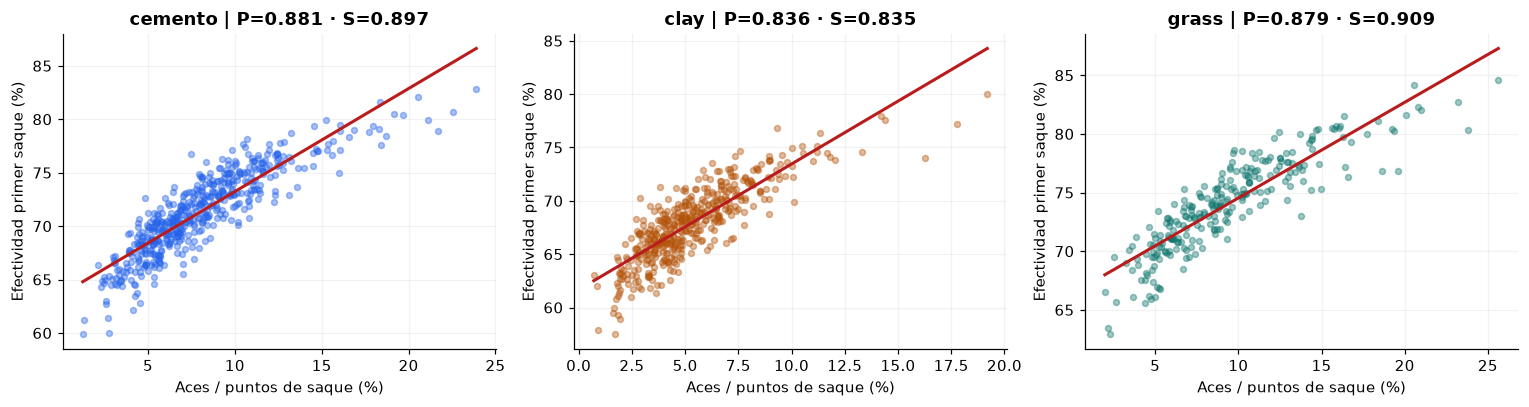

### H2 · Linealidad y redundancia

**1. Afirmación.** La tasa de aces aumenta de forma aproximadamente lineal con la efectividad del primer saque.

**2. Qué espero ver.** Pearson >0,6, Spearman también alto y diferencia absoluta entre ambos <0,05.

**3. Medida y gráfico.** Pearson, Spearman y recta por superficie; H2_pearson_spearman_recta.png.

**4. Resultado y zona.** n=1224; Pearson=0.8637 (verde); Spearman=0.8785; |Spearman−Pearson|=0.0148. CONFIRMADA.

**5. Movimiento.** 0 movimientos: Pearson llega a verde, Spearman confirma el orden y la brecha pequeña respalda la forma lineal.

**6. Qué hago con eso.** Las variables son muy redundantes. Entra tasa_aces, por interpretación directa, y sale efectividad_primero del clustering para no duplicar peso.

In [8]:
h2base = perfiles_superficie.loc[
    perfiles_superficie.informacion_suficiente
].dropna(subset=['tasa_aces','efectividad_primero']).copy()

def estandarizar_por_superficie(datos, variable, salida):
    datos[salida] = datos.groupby('superficie')[variable].transform(
        lambda x: (x - x.mean()) / x.std())

estandarizar_por_superficie(h2base,'tasa_aces','aces_z')
estandarizar_por_superficie(h2base,'efectividad_primero','primer_saque_z')
h2 = asociacion(h2base.aces_z,h2base.primer_saque_z)
brecha_h2 = abs(h2['spearman'] - h2['pearson'])

fig,axes=plt.subplots(1,3,figsize=(14,3.8))
resultados_superficie=[]
for ax,(nombre_superficie,grupo) in zip(axes,h2base.groupby('superficie',sort=False)):
    a=asociacion(grupo.tasa_aces,grupo.efectividad_primero)
    resultados_superficie.append({'superficie':nombre_superficie,'n':a['n'],
                                   'pearson':a['pearson'],'spearman':a['spearman']})
    ax.scatter(grupo.tasa_aces*100,grupo.efectividad_primero*100,s=15,alpha=.4,
               color=colores_superficie[nombre_superficie])
    pendiente,intercepto=np.polyfit(grupo.tasa_aces*100,grupo.efectividad_primero*100,1)
    xline=np.linspace(grupo.tasa_aces.min()*100,grupo.tasa_aces.max()*100,100)
    ax.plot(xline,pendiente*xline+intercepto,color=ROJO,linewidth=2)
    ax.set(xlabel='Aces / puntos de saque (%)',ylabel='Efectividad primer saque (%)',
           title=f'{nombre_superficie} | P={a["pearson"]:.3f} · S={a["spearman"]:.3f}')
grafico('H2_pearson_spearman_recta')
tabla_h2_superficie=pd.DataFrame(resultados_superficie)
exportar(tabla_h2_superficie,'H2_pearson_spearman_por_superficie',False)

z2 = zona(h2['pearson'],'correlacion')
estado2 = 'confirmada' if z2=='verde' and h2['pearson']>0 and brecha_h2<.05 else 'refutada' if z2=='rojo' else 'inconclusa'
ficha('H2','Linealidad y redundancia',
    'La tasa de aces aumenta de forma aproximadamente lineal con la efectividad del primer saque.',
    'Pearson >0,6, Spearman también alto y diferencia absoluta entre ambos <0,05.',
    'Pearson, Spearman y recta por superficie; H2_pearson_spearman_recta.png.',
    f'n={h2["n"]}; Pearson={h2["pearson"]:.4f} ({z2}); Spearman={h2["spearman"]:.4f}; '
    f'|Spearman−Pearson|={brecha_h2:.4f}. {estado2.upper()}.',
    '0 movimientos: Pearson llega a verde, Spearman confirma el orden y la brecha pequeña respalda la forma lineal.',
    'Las variables son muy redundantes. Entra tasa_aces, por interpretación directa, y sale efectividad_primero del clustering para no duplicar peso.',
    h2['pearson'],'correlacion',estado2,h2['n'])

### H3 · Adaptación del servicio entre grass y clay
**Antes de calcular:** espero asociación positiva fuerte (Pearson >0,6) entre
el perfil sacador y la ventaja de rendimiento en grass frente a clay. Se parte
con >=10 partidos y >=80% de cobertura de saque en ambas superficies.

Si queda amarilla, primero se controlará el nivel base del propio jugador usando
diferencias grass−clay; si persiste la forma de abanico, se exigirá más exposición.

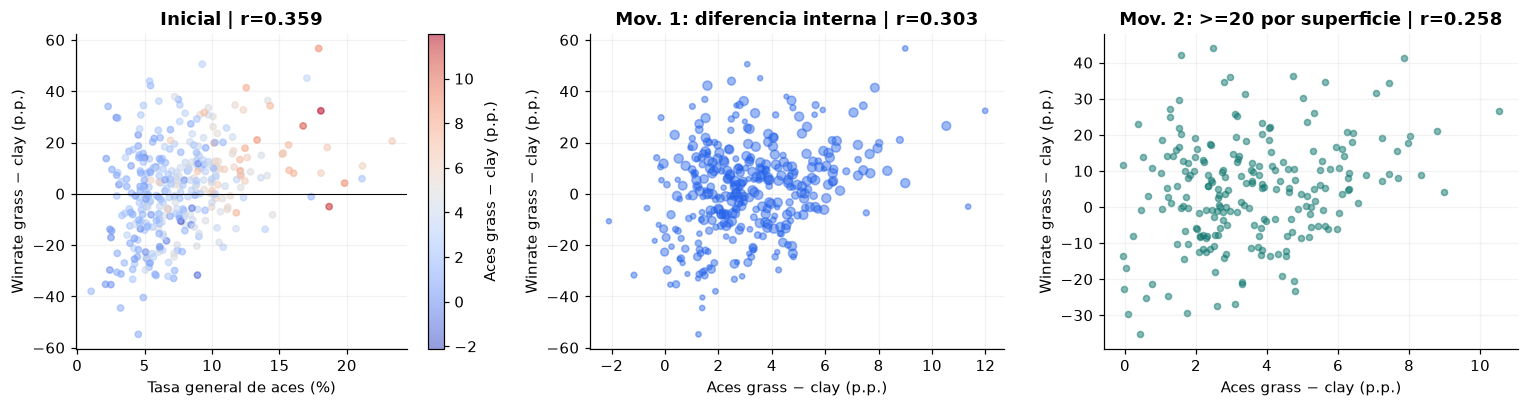

### H3 · Adaptación por superficie

**1. Afirmación.** El aumento de la capacidad de hacer aces en grass respecto de clay se acompaña de una mejora fuerte del rendimiento.

**2. Qué espero ver.** Pearson >0,6 y nube ascendente estable al controlar nivel base y exposición.

**3. Medida y gráfico.** Pearson y Spearman; tres paneles en H3_superficie_movimientos.png.

**4. Resultado y zona.** inicial n=350, r=0.3586 (amarillo); tras M1 r=0.3030 (amarillo); tras M2 n=221, r=0.2580 (amarillo). INCONCLUSA.

**5. Movimiento.** 2 movimientos: (1) controlar el nivel base con diferencias dentro del mismo jugador, motivado por el color del primer panel; (2) exigir >=20 partidos por superficie porque el segundo panel conserva un abanico amplio con menor exposición.

**6. Qué hago con eso.** Después de dos movimientos la relación sigue amarilla. Mantener superficie como contexto, pero no afirmar que aumentar aces cause una ventaja fuerte en grass.

In [9]:
superficie = df.set_index('id-jugador').copy()
base10 = (
    superficie['partidos-grass'].ge(10)
    & superficie['partidos-clay'].ge(10)
    & superficie['cobertura-saque-grass'].ge(MIN_COBERTURA)
    & superficie['cobertura-saque-clay'].ge(MIN_COBERTURA)
)
h3m = superficie.loc[base10].copy()
h3m['ventaja_grass_clay'] = h3m['tasa-victorias-grass'] - h3m['tasa-victorias-clay']
h3m['cambio_aces_grass_clay'] = h3m['tasa-aces-grass'] - h3m['tasa-aces-clay']
h3_0 = asociacion(h3m['tasa-aces-totales'],h3m.ventaja_grass_clay)
h3_1 = asociacion(h3m.cambio_aces_grass_clay,h3m.ventaja_grass_clay)

base20 = base10 & superficie['partidos-grass'].ge(20) & superficie['partidos-clay'].ge(20)
h3estable = superficie.loc[base20].copy()
h3estable['ventaja_grass_clay'] = h3estable['tasa-victorias-grass'] - h3estable['tasa-victorias-clay']
h3estable['cambio_aces_grass_clay'] = h3estable['tasa-aces-grass'] - h3estable['tasa-aces-clay']
h3_2 = asociacion(h3estable.cambio_aces_grass_clay,h3estable.ventaja_grass_clay)

fig,axes=plt.subplots(1,3,figsize=(14,3.8))
sc=axes[0].scatter(h3m['tasa-aces-totales']*100,h3m.ventaja_grass_clay*100,
                   c=h3m.cambio_aces_grass_clay*100,s=17,alpha=.55,cmap='coolwarm')
axes[0].axhline(0,color='black',linewidth=.7)
axes[0].set(xlabel='Tasa general de aces (%)',ylabel='Winrate grass − clay (p.p.)',
            title=f'Inicial | r={h3_0["pearson"]:.3f}')
fig.colorbar(sc,ax=axes[0],label='Aces grass − clay (p.p.)')
axes[1].scatter(h3m.cambio_aces_grass_clay*100,h3m.ventaja_grass_clay*100,
                s=np.clip(h3m[['partidos-grass','partidos-clay']].min(axis=1),8,35),alpha=.45,color=AZUL)
axes[1].set(xlabel='Aces grass − clay (p.p.)',ylabel='Winrate grass − clay (p.p.)',
            title=f'Mov. 1: diferencia interna | r={h3_1["pearson"]:.3f}')
axes[2].scatter(h3estable.cambio_aces_grass_clay*100,h3estable.ventaja_grass_clay*100,
                s=16,alpha=.5,color=VERDE)
axes[2].set(xlabel='Aces grass − clay (p.p.)',ylabel='Winrate grass − clay (p.p.)',
            title=f'Mov. 2: >=20 por superficie | r={h3_2["pearson"]:.3f}')
grafico('H3_superficie_movimientos')

z3_0,z3_1,z3 = [zona(h['pearson'],'correlacion') for h in [h3_0,h3_1,h3_2]]
estado3 = 'confirmada' if z3=='verde' and h3_2['pearson']>0 else 'refutada' if z3=='rojo' or h3_2['pearson']<0 else 'inconclusa'
ficha('H3','Adaptación por superficie',
    'El aumento de la capacidad de hacer aces en grass respecto de clay se acompaña de una mejora fuerte del rendimiento.',
    'Pearson >0,6 y nube ascendente estable al controlar nivel base y exposición.',
    'Pearson y Spearman; tres paneles en H3_superficie_movimientos.png.',
    f'inicial n={h3_0["n"]}, r={h3_0["pearson"]:.4f} ({z3_0}); '
    f'tras M1 r={h3_1["pearson"]:.4f} ({z3_1}); tras M2 n={h3_2["n"]}, '
    f'r={h3_2["pearson"]:.4f} ({z3}). {estado3.upper()}.',
    '2 movimientos: (1) controlar el nivel base con diferencias dentro del mismo jugador, motivado por el color del primer panel; '
    '(2) exigir >=20 partidos por superficie porque el segundo panel conserva un abanico amplio con menor exposición.',
    'Después de dos movimientos la relación sigue amarilla. Mantener superficie como contexto, pero no afirmar que aumentar aces cause una ventaja fuerte en grass.',
    h3_2['pearson'],'correlacion',estado3,h3_2['n'])

### H4 · Segundo saque y ganador más allá del ranking
**Antes de calcular:** espero que la diferencia histórica de efectividad del
segundo saque separe fuertemente a `gana_a` (η² >0,25). Si la primera medida
queda amarilla y el gráfico muestra relación con ranking, se controlará esa
tercera variable usando partidos de ranking cercano:
`|log(rank A) − log(rank B)| <= 0,5`.

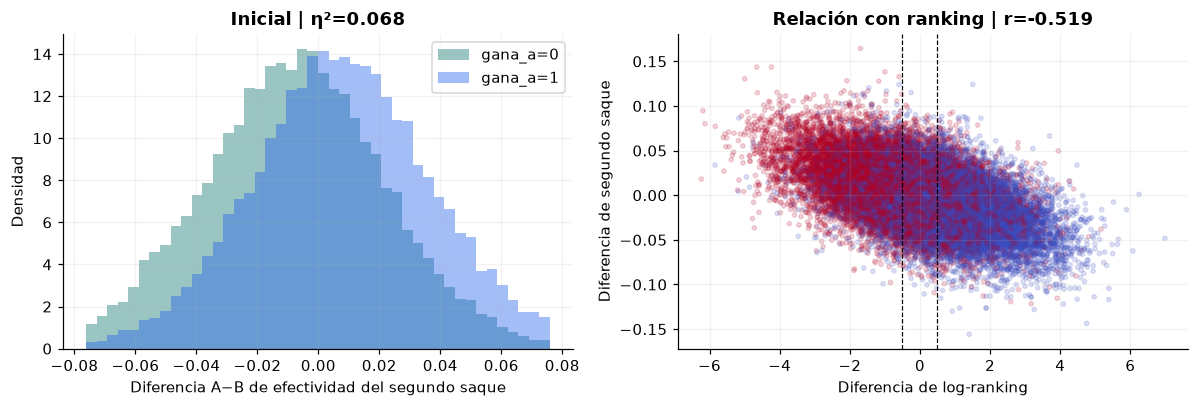

**Primera medida:** η²=0.0683, zona amarillo. La diferencia de segundo saque se asocia con la diferencia de ranking (r=-0.519); por eso corresponde controlar ranking, no cambiar escala ni buscar una superficie favorable.

In [10]:
e4_0 = eta2(dev.dif_efectividad_segundo,dev.gana_a)
corr_estilo_ranking = dev[['dif_efectividad_segundo','dif_log_ranking']].corr().iloc[0,1]
ranking_cercano = dev.dif_log_ranking.abs().le(.5)
h4cerca = dev.loc[ranking_cercano].copy()
e4_1 = eta2(h4cerca.dif_efectividad_segundo,h4cerca.gana_a)

fig,axes=plt.subplots(1,2,figsize=(11,3.8))
bins=np.linspace(dev.dif_efectividad_segundo.quantile(.01),dev.dif_efectividad_segundo.quantile(.99),45)
for y,c in [(0,VERDE),(1,AZUL)]:
    axes[0].hist(dev.loc[dev.gana_a.eq(y),'dif_efectividad_segundo'],bins=bins,density=True,
                 alpha=.42,color=c,label=f'gana_a={y}')
axes[0].set(xlabel='Diferencia A−B de efectividad del segundo saque',ylabel='Densidad',
            title=f'Inicial | η²={e4_0:.3f}')
axes[0].legend()
sc=axes[1].scatter(dev.dif_log_ranking,dev.dif_efectividad_segundo,
                   c=dev.gana_a,cmap='coolwarm',s=8,alpha=.16)
axes[1].axvline(-.5,color='black',linestyle='--',linewidth=.8)
axes[1].axvline(.5,color='black',linestyle='--',linewidth=.8)
axes[1].set(xlabel='Diferencia de log-ranking',ylabel='Diferencia de segundo saque',
            title=f'Relación con ranking | r={corr_estilo_ranking:.3f}')
grafico('H4_segundo_saque_control_ranking')
texto(f'**Primera medida:** η²={e4_0:.4f}, zona {zona(e4_0,"eta2")}. '
      f'La diferencia de segundo saque se asocia con la diferencia de ranking (r={corr_estilo_ranking:.3f}); '
      'por eso corresponde controlar ranking, no cambiar escala ni buscar una superficie favorable.')

In [11]:
z4_0 = zona(e4_0,'eta2')
z4 = zona(e4_1,'eta2')
estado4 = 'confirmada' if z4=='verde' else 'refutada' if z4=='rojo' else 'inconclusa'
ficha('H4','Columna predictiva más allá del ranking',
    'La diferencia histórica de efectividad del segundo saque aporta una separación fuerte del ganador, independiente del ranking.',
    'η² >0,25 global y señal conservada entre rivales de ranking cercano.',
    'η² y gráficos de distribución/relación con ranking en H4_segundo_saque_control_ranking.png.',
    f'inicial n={dev.dif_efectividad_segundo.notna().sum()}, η²={e4_0:.4f} ({z4_0}); '
    f'tras controlar ranking n={h4cerca.dif_efectividad_segundo.notna().sum()}, η²={e4_1:.4f} ({z4}). {estado4.upper()}.',
    '1 movimiento: controlar ranking con rivales cercanos, porque el segundo panel muestra asociación entre la feature y el ranking. '
    'El resultado pasa a rojo; rojo termina la prueba y no habilita un segundo movimiento.',
    'Sale del modelo predictivo principal: no mostró señal fuerte independiente del ranking. Se conserva únicamente como rasgo técnico para construir estilos.',
    e4_1,'eta2',estado4,h4cerca.dif_efectividad_segundo.notna().sum())

### H4 · Columna predictiva más allá del ranking

**1. Afirmación.** La diferencia histórica de efectividad del segundo saque aporta una separación fuerte del ganador, independiente del ranking.

**2. Qué espero ver.** η² >0,25 global y señal conservada entre rivales de ranking cercano.

**3. Medida y gráfico.** η² y gráficos de distribución/relación con ranking en H4_segundo_saque_control_ranking.png.

**4. Resultado y zona.** inicial n=42161, η²=0.0683 (amarillo); tras controlar ranking n=12042, η²=0.0074 (rojo). REFUTADA.

**5. Movimiento.** 1 movimiento: controlar ranking con rivales cercanos, porque el segundo panel muestra asociación entre la feature y el ranking. El resultado pasa a rojo; rojo termina la prueba y no habilita un segundo movimiento.

**6. Qué hago con eso.** Sale del modelo predictivo principal: no mostró señal fuerte independiente del ranking. Se conserva únicamente como rasgo técnico para construir estilos.

### H5 · Compromiso de riesgo en el servicio: aces y dobles faltas
**Antes de calcular:** espero una asociación positiva (Pearson >0,20) entre
la tasa de aces y la tasa de dobles faltas: asumir más riesgo al sacar para conseguir
puntos directos suele acarrear mayor frecuencia de errores no forzados de servicio.

Si queda amarilla, se controlará la superficie mediante estandarización interna
y luego se exigirá mayor exposición (>=50 partidos).

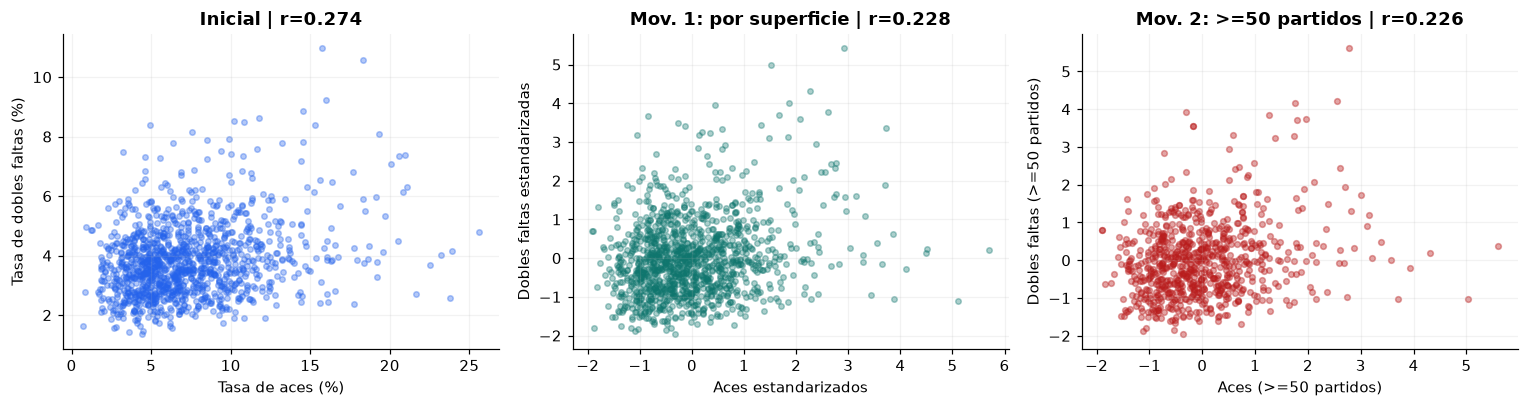

### H5 · Compromiso de riesgo en el servicio

**1. Afirmación.** Buscar mayor cantidad de aces implica asumir un mayor riesgo que se traduce en una mayor tasa de dobles faltas.

**2. Qué espero ver.** Pearson >0,6 para confirmación fuerte; o asociación positiva estable en zona amarilla.

**3. Medida y gráfico.** Pearson y Spearman entre tasas de saque; H5_aces_dobles_faltas_movimientos.png.

**4. Resultado y zona.** inicial n=1224, r=0.2743 (amarillo); tras M1 r=0.2276 (amarillo); tras M2 n=748, r=0.2256 (amarillo). INCONCLUSA.

**5. Movimiento.** 2 movimientos: (1) estandarizar dentro de cada superficie para neutralizar condiciones de velocidad; (2) exigir >=50 partidos al persistir dispersión en perfiles con menor muestra.

**6. Qué hago con eso.** La relación positiva persiste en zona amarilla. Ambas métricas deben coexistir como dimensiones técnicas independientes en el clustering.

In [12]:
h5base = perfiles_superficie.loc[
    perfiles_superficie.informacion_suficiente
].dropna(subset=['tasa_aces', 'tasa_dobles_faltas']).copy()

estandarizar_por_superficie(h5base, 'tasa_aces', 'aces_z_h5')
estandarizar_por_superficie(h5base, 'tasa_dobles_faltas', 'df_z_h5')

h5_0 = asociacion(h5base.tasa_aces, h5base.tasa_dobles_faltas)
h5_1 = asociacion(h5base.aces_z_h5, h5base.df_z_h5)

h5estable = h5base.loc[h5base.partidos.ge(50)].copy()
estandarizar_por_superficie(h5estable, 'tasa_aces', 'aces_z_h5')
estandarizar_por_superficie(h5estable, 'tasa_dobles_faltas', 'df_z_h5')
h5_2 = asociacion(h5estable.aces_z_h5, h5estable.df_z_h5)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
axes[0].scatter(h5base.tasa_aces * 100, h5base.tasa_dobles_faltas * 100, s=13, alpha=.35, color=AZUL)
axes[0].set(xlabel='Tasa de aces (%)', ylabel='Tasa de dobles faltas (%)',
            title=f'Inicial | r={h5_0["pearson"]:.3f}')

axes[1].scatter(h5base.aces_z_h5, h5base.df_z_h5, s=13, alpha=.35, color=VERDE)
axes[1].set(xlabel='Aces estandarizados', ylabel='Dobles faltas estandarizadas',
            title=f'Mov. 1: por superficie | r={h5_1["pearson"]:.3f}')

axes[2].scatter(h5estable.aces_z_h5, h5estable.df_z_h5, s=14, alpha=.4, color=ROJO)
axes[2].set(xlabel='Aces (>=50 partidos)', ylabel='Dobles faltas (>=50 partidos)',
            title=f'Mov. 2: >=50 partidos | r={h5_2["pearson"]:.3f}')
grafico('H5_aces_dobles_faltas_movimientos')

z5_0, z5_1, z5 = [zona(h['pearson'], 'correlacion') for h in [h5_0, h5_1, h5_2]]
estado5 = 'confirmada' if z5 == 'verde' and h5_2['pearson'] > 0 else 'refutada' if z5 == 'rojo' or h5_2['pearson'] < 0 else 'inconclusa'
ficha('H5', 'Compromiso de riesgo en el servicio',
    'Buscar mayor cantidad de aces implica asumir un mayor riesgo que se traduce en una mayor tasa de dobles faltas.',
    'Pearson >0,6 para confirmación fuerte; o asociación positiva estable en zona amarilla.',
    'Pearson y Spearman entre tasas de saque; H5_aces_dobles_faltas_movimientos.png.',
    f'inicial n={h5_0["n"]}, r={h5_0["pearson"]:.4f} ({z5_0}); tras M1 r={h5_1["pearson"]:.4f} ({z5_1}); '
    f'tras M2 n={h5_2["n"]}, r={h5_2["pearson"]:.4f} ({z5}). {estado5.upper()}.',
    '2 movimientos: (1) estandarizar dentro de cada superficie para neutralizar condiciones de velocidad; '
    '(2) exigir >=50 partidos al persistir dispersión en perfiles con menor muestra.',
    'La relación positiva persiste en zona amarilla. Ambas métricas deben coexistir como dimensiones técnicas independientes en el clustering.',
    h5_2['pearson'], 'correlacion', estado5, h5_2['n'])

In [13]:
resumen_fichas=pd.DataFrame(fichas)
exportar(resumen_fichas,'fichas_hipotesis',False)
def color_zona(v):
    colores={'verde':'#dcfce7','amarillo':'#fef3c7','rojo':'#fee2e2'}
    return 'background-color: '+colores.get(v,'#f1f5f9')+'; color: #111827;'
display(resumen_fichas[['id','tipo','n','valor','zona','estado']].style.format({'valor':'{:.4f}'}).map(color_zona,subset=['zona']))
assert len(fichas)==5 and any(f['estado']=='inconclusa' for f in fichas)
assert all('2 movimientos' in f['movimiento'] for f in fichas if f['estado']=='inconclusa')

,id,tipo,n,valor,zona,estado
0,H1,Pocos partidos y valores extremos,3252,0.9644,verde,confirmada
1,H2,Linealidad y redundancia,1224,0.8637,verde,confirmada
2,H3,Adaptación por superficie,221,0.2580,amarillo,inconclusa
3,H4,Columna predictiva más allá del ranking,12042,0.0074,rojo,refutada
4,H5,Compromiso de riesgo en el servicio,748,0.2256,amarillo,inconclusa


## 6. Sensibilidad y relaciones complementarias

La sensibilidad comprueba que la relación lineal de H2 se mantenga con mínimos
de 20, 50 y 100 partidos por superficie. La matriz se calcula sobre los siete
rasgos finales del clustering, después de retirar `efectividad_primero` por
redundancia.

,min_partidos_superficie,n_perfiles,pearson,spearman,brecha_absoluta,zona
0,20,1224,0.8637,0.8785,0.0148,verde
1,50,748,0.8839,0.8929,0.0091,verde
2,100,413,0.9052,0.9236,0.0184,verde


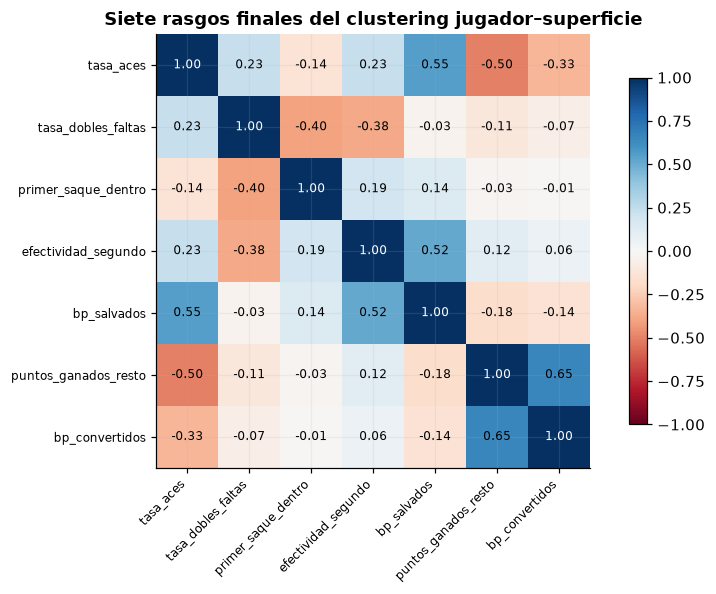

**Decisión:** entrenar el clustering con siete rasgos. `efectividad_primero` sale por redundancia con `tasa_aces`; victorias, superficie, ranking, títulos y cobertura tampoco forman la distancia.

In [14]:
sens=[]
for minimo in [20,50,100]:
    v=perfiles_superficie.loc[
        perfiles_superficie.informacion_suficiente
        & perfiles_superficie.partidos.ge(minimo)
    ].dropna(subset=['tasa_aces','efectividad_primero']).copy()
    estandarizar_por_superficie(v,'tasa_aces','aces_z')
    estandarizar_por_superficie(v,'efectividad_primero','primer_saque_z')
    a=asociacion(v.aces_z,v.primer_saque_z)
    sens.append({'min_partidos_superficie':minimo,'n_perfiles':a['n'],
                 'pearson':a['pearson'],'spearman':a['spearman'],
                 'brecha_absoluta':abs(a['spearman']-a['pearson']),
                 'zona':zona(a['pearson'],'correlacion')})
exportar(pd.DataFrame(sens),'sensibilidad_filtros')

VARIABLES_CLUSTER = [c for c in RATIOS if c != 'efectividad_primero']
base_confiable = perfiles_superficie.loc[perfiles_superficie.informacion_suficiente].copy()
cluster_base = base_confiable[VARIABLES_CLUSTER].copy()
for variable in VARIABLES_CLUSTER:
    cluster_base[variable] = base_confiable.groupby('superficie')[variable].transform(
        lambda x:(x-x.mean())/x.std())
corr=cluster_base.corr()
fig,ax=plt.subplots(figsize=(8,5.5))
im=ax.imshow(corr,vmin=-1,vmax=1,cmap='RdBu')
ax.set_xticks(range(len(corr)),corr.columns,rotation=45,ha='right',fontsize=8)
ax.set_yticks(range(len(corr)),corr.columns,fontsize=8)
for i in range(len(corr)):
    for k in range(len(corr)):
        ax.text(k,i,f'{corr.iloc[i,k]:.2f}',ha='center',va='center',fontsize=8,
                color='white' if abs(corr.iloc[i,k])>.7 else 'black')
ax.set_title('Siete rasgos finales del clustering jugador–superficie')
fig.colorbar(im,ax=ax,shrink=.8)
grafico('05_correlacion_rasgos')
texto('**Decisión:** entrenar el clustering con siete rasgos. `efectividad_primero` sale por redundancia con `tasa_aces`; '
      'victorias, superficie, ranking, títulos y cobertura tampoco forman la distancia.')

## 7. Tabla definitiva de columnas y control de fuga

Esta es la especificación cerrada que pasa a la Entrega 3. Cada fila tiene una
decisión definitiva: **entra**, **sale**, **filtro**, **objetivo** o **metadato**.

En esta tabla la zona se presenta sólo como **verde**, **amarillo** o **rojo**:

- **Verde:** la columna queda aceptada para el papel declarado y no presenta fuga.
- **Amarillo:** entra con evidencia parcial, transformación o construcción histórica.
- **Rojo:** sale de esa etapa por fuga, circularidad, constancia o evidencia insuficiente.

La decisión es la que manda. Una columna amarilla puede entrar como control y una
columna roja puede conservarse en otra etapa distinta. Para partidos históricos,
toda tasa, experiencia o estilo se calcula exclusivamente con información anterior.

In [15]:
candidatas=[]
def candidata(etapa,col,mide,z,decision,existe):
    candidatas.append({'etapa':etapa,'columna':col,'que_mide':mide,'zona':z,
                       'decision':decision,'existiria_al_predecir':existe})

# En formato largo estos nombres representan la variante de la superficie de la fila.
zonas_cluster = {'tasa_aces':'verde','efectividad_primero':'verde'}
for nombre_interno in RATIOS:
    decision_cluster = ('Sale del clustering por redundancia confirmada en H2; se conserva tasa_aces.'
                        if nombre_interno=='efectividad_primero' else
                        'Entra al clustering. Usar la versión de la superficie y estandarizar dentro de superficie.')
    candidata('Clustering jugador–superficie',nombre_interno,SIGNIFICADOS[nombre_interno],
        zonas_cluster.get(nombre_interno,'verde'),decision_cluster,
        'Sí, si el perfil usa solamente partidos anteriores.')

for col,mide,z,decision in [
    ('partidos','Exposición en la superficie','verde','Filtro definitivo: >=20 partidos; no entra en X.'),
    ('cobertura_saque','Calidad de estadísticas de saque','verde','Filtro definitivo: >=80%; no entra en X.'),
    ('cobertura_resto','Calidad de estadísticas de devolución','verde','Filtro definitivo: >=80%; no entra en X.'),
    ('superficie','Identifica el perfil jugador–superficie','verde','No entra en la distancia; define la fila y la estandarización.'),
    ('winrate','Rendimiento en la superficie','rojo','Sale del clustering para evitar circularidad; mide superioridad después.'),
    ('ranking','Fuerza competitiva','rojo','Sale del clustering; se usa en el modelo base.'),
    ('titulos','Éxito acumulado','rojo','Sale del clustering; se reserva para evaluación externa.'),
    ('titulos-1000-grass','Columna constante en este snapshot','rojo','Sale porque no aporta variación.'),
]:
    candidata('Clustering jugador–superficie',col,mide,z,decision,
              'Sí sólo en versión histórica cuando corresponda.')

eta_rank = eta2(dev.dif_log_ranking,dev.gana_a)
eta_experiencia = eta2(dev.dif_partidos_log,dev.gana_a)
eta_winrate = eta2(dev.dif_winrate,dev.gana_a)
candidata('Modelo base','dif_log_ranking','Diferencia logarítmica de ranking A−B',
          zona(eta_rank,'eta2'),
          'Entra transformada; referencia principal que el modelo ampliado debe superar.','Sí, antes del partido.')
candidata('Modelo base','dif_partidos_log','Diferencia A−B de experiencia histórica en escala log1p',
          zona(eta_experiencia,'eta2'),
          'Entra transformada como control de experiencia y confiabilidad del estilo.','Sí, usando historial anterior.')
candidata('Modelo base','dif_winrate','Diferencia A−B de tasa histórica de victorias',
          zona(eta_winrate,'eta2'),
          'Entra como control histórico de fuerza.','Sí, usando únicamente partidos anteriores.')
for col in ['surface','tourney_level','best_of']:
    candidata('Modelo base',col,'Contexto conocido del encuentro','verde',
              'Entra al modelo base y al ampliado.','Sí, antes del partido.')

for col,mide in [
    ('estilo_a','Estilo de A en la superficie del partido'),
    ('estilo_b','Estilo de B en la superficie del partido'),
    ('interaccion_estilos','Combinación estilo A × estilo B'),
]:
    candidata('Modelo ampliado',col,mide,'amarillo',
              'Entra obligatoriamente al modelo ampliado; se deriva del clustering jugador–superficie.',
              'Sí, si el cluster se ajusta únicamente con historial anterior.')

candidata('Modelo ampliado','dif_efectividad_segundo','Diferencia histórica del segundo saque','rojo',
          'Sale como predictor aislado por H4; permanece dentro del clustering técnico.',
          'Sí en versión histórica, pero H4 decide excluirla como predictor aislado.')

for col in ['winner_id','loser_id','score','minutes','w_ace','l_ace']:
    candidata('Control de fuga',col,'Resultado o estadística del partido actual','rojo',
              'Sale definitivamente por fuga.','No: se conoce durante o después del partido.')
for col in ['id_partido','id_a','id_b','fecha']:
    candidata('Trazabilidad',col,'Clave, identificación o corte temporal','verde',
              'Metadato; no entra como feature.','Sí, pero no mide habilidad.')
candidata('Objetivo','gana_a','1 si gana A; 0 si gana B','verde',
          'Objetivo y; nunca entra en X.','No: se observa al terminar.')

tabla_candidatas=pd.DataFrame(candidatas)
assert set(tabla_candidatas.zona).issubset({'verde','amarillo','rojo'})
exportar(tabla_candidatas,'columnas_candidatas',False)
display(tabla_candidatas.style.map(color_zona,subset=['zona']).set_properties(**{
    'white-space':'normal','text-align':'left','max-width':'320px','font-size':'12px'}))

# Decisión explícita para cada columna física del Silver.
decisiones=[]
tasas_base_superficie = [c.replace('-totales','') for c in RATIOS.values()]
for col in df.columns:
    es_tasa_superficie = any(col == f'{base}-{sup}' for base in tasas_base_superficie for sup in SUPERFICIES)
    if es_tasa_superficie:
        decision='Entra al perfil largo de su superficie'; motivo='Feature técnica del clustering'
    elif col.startswith('tasa-victorias-'):
        decision='Sale del clustering; mide superioridad'; motivo='Resultado, no definición de estilo'
    elif col.startswith(('cobertura-','partidos-')):
        decision='Filtro de calidad/exposición'; motivo='No entra a la distancia'
    elif col.endswith('-totales') and col.startswith(('tasa-','efectividad-')):
        decision='Diagnóstico global; sale del clustering por superficie'; motivo='Se usa la variante de cada superficie'
    elif col in constantes:
        decision='Sale: constante'; motivo='No aporta variación'
    elif col in ['id-jugador','nombre-jugador','pais','fecha-nacimiento','año-profesional']:
        decision='Metadato o contexto'; motivo='No entra al núcleo técnico'
    else:
        decision='Sale del núcleo; insumo, conteo o evaluación'; motivo='No define directamente el estilo técnico'
    decisiones.append({'columna':col,'decision':decision,'motivo':motivo})
exportar(pd.DataFrame(decisiones),'decisiones_columnas_silver',False)

,etapa,columna,que_mide,zona,decision,existiria_al_predecir
0,Clustering jugador–superficie,tasa_aces,Aces / puntos de saque: frecuencia de puntos ganados directamente con el servicio.,verde,Entra al clustering. Usar la versión de la superficie y estandarizar dentro de superficie.,"Sí, si el perfil usa solamente partidos anteriores."
1,Clustering jugador–superficie,tasa_dobles_faltas,Dobles faltas / puntos de saque: frecuencia de errores de ambos servicios.,verde,Entra al clustering. Usar la versión de la superficie y estandarizar dentro de superficie.,"Sí, si el perfil usa solamente partidos anteriores."
2,Clustering jugador–superficie,primer_saque_dentro,Primeros saques dentro / puntos de saque: regularidad del primer servicio.,verde,Entra al clustering. Usar la versión de la superficie y estandarizar dentro de superficie.,"Sí, si el perfil usa solamente partidos anteriores."
3,Clustering jugador–superficie,efectividad_primero,Puntos ganados con primer saque / primeros saques dentro: éxito cuando entra.,verde,Sale del clustering por redundancia confirmada en H2; se conserva tasa_aces.,"Sí, si el perfil usa solamente partidos anteriores."
4,Clustering jugador–superficie,efectividad_segundo,Puntos ganados con segundo saque / intentos de segundo saque.,verde,Entra al clustering. Usar la versión de la superficie y estandarizar dentro de superficie.,"Sí, si el perfil usa solamente partidos anteriores."
5,Clustering jugador–superficie,bp_salvados,Break points salvados / enfrentados: quiebres evitados al sacar.,verde,Entra al clustering. Usar la versión de la superficie y estandarizar dentro de superficie.,"Sí, si el perfil usa solamente partidos anteriores."
6,Clustering jugador–superficie,puntos_ganados_resto,Puntos que el rival no ganó al sacar / puntos de saque del rival.,verde,Entra al clustering. Usar la versión de la superficie y estandarizar dentro de superficie.,"Sí, si el perfil usa solamente partidos anteriores."
7,Clustering jugador–superficie,bp_convertidos,Break points no salvados por el rival / oportunidades del jugador.,verde,Entra al clustering. Usar la versión de la superficie y estandarizar dentro de superficie.,"Sí, si el perfil usa solamente partidos anteriores."
8,Clustering jugador–superficie,partidos,Exposición en la superficie,verde,Filtro definitivo: >=20 partidos; no entra en X.,Sí sólo en versión histórica cuando corresponda.
9,Clustering jugador–superficie,cobertura_saque,Calidad de estadísticas de saque,verde,Filtro definitivo: >=80%; no entra en X.,Sí sólo en versión histórica cuando corresponda.


## 8. Decisiones para la Entrega 3 y límites

1. **Unidad del estilo:** jugador–superficie. Un tenista puede recibir un estilo
   distinto en cemento, clay y grass.
2. **Confiabilidad:** H1 confirma que los perfiles con menos de 20 partidos
   presentan valores más extremos en la efectividad del segundo saque. El mínimo
   de partidos y la cobertura son filtros, no características del estilo.
3. **Siete rasgos:** H2 confirma una relación casi lineal entre tasa de aces y
   efectividad del primer saque. Se conserva `tasa_aces` y sale
   `efectividad_primero` para no duplicar peso en la distancia.
4. **Superioridad:** winrate, ranking y títulos no construyen clusters; se usan
   después para comparar resultados sin circularidad.
5. **Adaptación:** H3 queda inconclusa después de dos movimientos; no se afirma
   una ventaja fuerte en grass basada únicamente en aces.
6. **Riesgo del servicio:** H5 contrasta si una mayor tasa de aces convive con más
   dobles faltas. Si la relación permanece amarilla tras dos movimientos, ambas
   variables se conservan como dimensiones técnicas distintas.
7. **Predicción:** el modelo base usa log-ranking, experiencia, winrate histórico
   y contexto. El ampliado agrega estilo A, estilo B e interacción.
8. **Fuga:** estilos y tasas históricos se calculan sólo con datos anteriores.

### Lo que queda para la Entrega 3

Estandarizar dentro de cada superficie usando sólo entrenamiento, aprender el
clustering con los siete rasgos definidos, interpretar centroides, asignar
estilos y comparar el modelo ampliado contra el modelo base con la misma reserva
temporal.

### Fuentes locales usadas
- `Practica/Unidad 2/Hipotesis_sobre_el_canonico.ipynb`.
- `Practica/Unidad 2/EDA_del_dataset_canonico.ipynb`.
- `Teoria/Unidad2/2026 - EDA.pdf`.
- Consigna de Entrega 2.
- `airflow-atp/include/atp/dataset_jugadores.py` y los CSV de Silver.